# 01 - Data Exploration

## Objective
- Load `clinical_data.txt`
- Load `case_*.csv` files
- Inspect data structure
- Check missing values
- Check temporal length
- Create an initial simple plot

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

/root/projects/diabetes_project


In [3]:
from src.data_utils import load_dataset

In [ ]:
# Reload module to avoid cache and ensure the edited version is used
from importlib import reload
import src.data_utils
reload(src.data_utils)
from src.data_utils import load_dataset
clinical, patients = load_dataset()
print("Clinical data shape:", clinical.shape)
print("Number of patients loaded:", len(patients))

Clinical data shape: (208, 7)
Number of patients loaded: 208


In [5]:
clinical.head()

,gender,age,BMI,glycaemia,HbA1c,follow.up,T2DM
1,1,77,25.4,106,6.3,413.0,False
2,0,42,30.0,92,5.8,1185.0,False
3,0,61,33.8,114,5.5,560.0,False
4,0,67,26.7,110,6.0,1183.0,False
5,1,53,25.8,106,5.2,918.0,False


In [6]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 1 to 209
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gender     208 non-null    int64  
 1   age        208 non-null    int64  
 2   BMI        207 non-null    float64
 3   glycaemia  208 non-null    int64  
 4   HbA1c      200 non-null    float64
 5   follow.up  196 non-null    float64
 6   T2DM       208 non-null    bool   
dtypes: bool(1), float64(3), int64(3)
memory usage: 11.6 KB


In [7]:
clinical.columns.tolist()

['gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow.up', 'T2DM']

In [8]:
patients[1].head()

,Unnamed: 0,hora,glucemia
0,1,00:00:14,86.0
1,2,00:05:14,81.0
2,3,00:10:14,78.0
3,4,00:15:14,76.0
4,5,00:20:14,76.0


In [9]:
patients[1].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  576 non-null    int64  
 1   hora        576 non-null    object 
 2   glucemia    567 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 13.6+ KB


In [10]:
patients[1].columns.tolist()

['Unnamed: 0', 'hora', 'glucemia']

In [11]:
print("Clinical columns:", clinical.columns.tolist())
print("Case 1 columns:", patients[1].columns.tolist())

Clinical columns: ['gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow.up', 'T2DM']
Case 1 columns: ['Unnamed: 0', 'hora', 'glucemia']


In [12]:
n_points = {case_id: len(df) for case_id, df in patients.items()}
n_points_series = pd.Series(n_points, name="n_points")

n_points_series.describe()

count    208.000000
mean     552.461538
std       79.089129
min      288.000000
25%      576.000000
50%      576.000000
75%      576.000000
max      576.000000
Name: n_points, dtype: float64

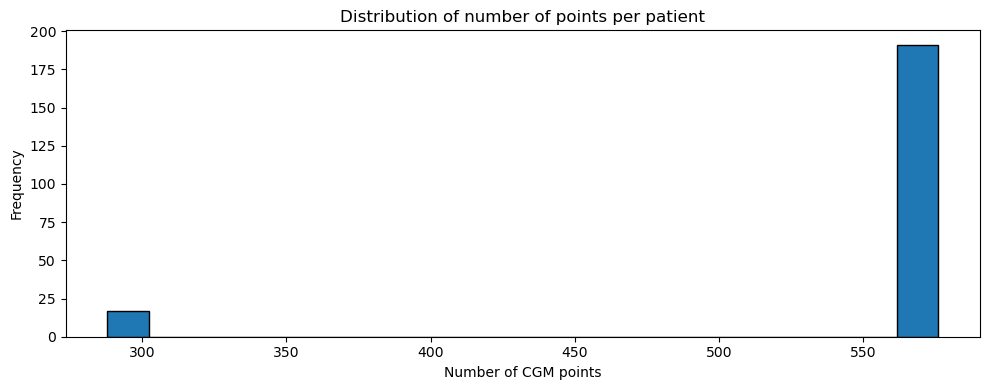

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(n_points_series, bins=20, edgecolor="black")
plt.xlabel("Number of CGM points")
plt.ylabel("Frequency")
plt.title("Distribution of number of points per patient")
plt.tight_layout()
plt.show()

In [15]:
# Normalize patient case structure
import importlib
import src.data_utils as data_utils

importlib.reload(data_utils)
from src.data_utils import standardize_case

patients_std = {k: standardize_case(v) for k, v in patients.items()}

print(patients_std[1].head())
print(patients_std[1].columns.tolist())
print(patients_std[1].shape)

                 time  glucose
0 1900-01-01 00:00:14     96.5
1 1900-01-01 00:05:14     93.0
2 1900-01-01 00:10:14     91.0
3 1900-01-01 00:15:14     89.5
4 1900-01-01 00:20:14     89.5
['time', 'glucose']
(288, 2)


In [ ]:
# Are there duplicates in time?
patients_std[1]["time"].value_counts().head()

time
00:00:14    2
00:05:14    2
00:10:14    2
00:15:14    2
00:20:14    2
Name: count, dtype: int64

In [ ]:
# Are the timestamps duplicated? Or is it a bug in my code?
patients[1]["hora"].value_counts().head()

hora
00:00:14    2
00:05:14    2
00:10:14    2
00:15:14    2
00:20:14    2
Name: count, dtype: int64

In [ ]:
print(len(patients[1]))
print(patients[1]["hora"].nunique())

576
331


In [ ]:
patients[1].groupby("hora")["glucemia"].nunique().value_counts()

glucemia
2    242
1     82
0      7
Name: count, dtype: int64

### Key findings on CGM data quality

- Many timestamps are duplicated, but not all (331 unique times, 576 rows).
- Some time points have 2 values (duplicates), some 1 (normal), and some 0 (missing).
- The dataset has both duplicates and missing values—it's not fully clean.
- Next step: average duplicates and handle missing values before further analysis.

### Next steps: Data cleaning pipeline

- **Step 1:** Group duplicate timestamps and average glucose values.
- **Step 2:** Convert time column to datetime format.
- **Step 3:** Create a complete timeline with 5-minute intervals (ensures regular sampling, as required by the paper).
- **Step 4:** Measure missing values after reindexing.
- **Step 5:** Interpolate missing glucose values.

We will update the `standardize_case` function to implement this pipeline for each patient.

In [ ]:
patients_std[1].head()

,time,glucose
0,1900-01-01 00:00:14,96.5
1,1900-01-01 00:05:14,93.0
2,1900-01-01 00:10:14,91.0
3,1900-01-01 00:15:14,89.5
4,1900-01-01 00:20:14,89.5


In [ ]:
patients_std[1].head(10)

,time,glucose
0,1900-01-01 00:00:14,96.5
1,1900-01-01 00:05:14,93.0
2,1900-01-01 00:10:14,91.0
3,1900-01-01 00:15:14,89.5
4,1900-01-01 00:20:14,89.5
5,1900-01-01 00:25:14,90.0
6,1900-01-01 00:30:14,91.0
7,1900-01-01 00:35:14,92.5
8,1900-01-01 00:40:14,93.5
9,1900-01-01 00:45:14,94.5


In [ ]:
patients_std[1].isna().sum()

time       0
glucose    0
dtype: int64

In [ ]:
patients_std[1][patients_std[1]["glucose"].isna()].head(20)

,time,glucose


In [ ]:
missing_summary = []

for case_id, df in patients_std.items():
    missing_glucose = df["glucose"].isna().sum()
    missing_pct = 100 * missing_glucose / len(df)

    missing_summary.append({
        "case_id": case_id,
        "n_points": len(df),
        "missing_glucose": missing_glucose,
        "missing_pct": missing_pct
    })

missing_df = pd.DataFrame(missing_summary)
missing_df.head()

,case_id,n_points,missing_glucose,missing_pct
0,1,288,0,0.000000
1,2,288,0,0.000000
2,3,288,26,9.027778
3,4,288,31,10.763889
4,5,288,37,12.847222


In [ ]:
missing_df["missing_pct"].describe()

count    208.000000
mean      17.647289
std       28.688736
min        0.000000
25%        0.000000
50%        8.333333
75%       13.541667
max       99.652778
Name: missing_pct, dtype: float64

### Data quality summary and next steps

- We now have a clear table of missing data percentage per patient (e.g., case 1 → 0%, case 3 → 9%, etc.).
- Globally, the mean missingness is ~17.6%, median ~8.3%, but some patients have up to 99.6% missing data.
- This shows a very heterogeneous dataset: many patients are almost complete, some have moderate missingness, and a few are almost empty.
- This is typical for real CGM data and matches what the paper expects: a per-patient report for possible exclusion.
- **Next:** Decide whom to exclude based on missingness (e.g., <10%: good, 10–30%: borderline, >30%: exclude).

In [ ]:
# Classify patient data quality based on missing percentage

def classify_quality(pct):
    if pct < 10:
        return "good"
    elif pct < 30:
        return "medium"
    else:
        return "bad"

missing_df["quality"] = missing_df["missing_pct"].apply(classify_quality)
missing_df.head()

,case_id,n_points,missing_glucose,missing_pct,quality
0,1,288,0,0.000000,good
1,2,288,0,0.000000,good
2,3,288,26,9.027778,good
3,4,288,31,10.763889,medium
4,5,288,37,12.847222,medium


In [ ]:
missing_df["quality"].value_counts()

quality
good      114
medium     60
bad        34
Name: count, dtype: int64

In [ ]:
# Check for missing values at the start and end of each patient series

def missing_edges(df, window=10):
    start_missing = df["glucose"].iloc[:window].isna().sum()
    end_missing = df["glucose"].iloc[-window:].isna().sum()
    return start_missing, end_missing

edge_summary = []
for case_id, df in patients_std.items():
    start_miss, end_miss = missing_edges(df)
    edge_summary.append({
        "case_id": case_id,
        "missing_start": start_miss,
        "missing_end": end_miss
    })

edges_df = pd.DataFrame(edge_summary)

# Combine with previous quality table
quality_full = missing_df.merge(edges_df, on="case_id")
quality_full.head()

,case_id,n_points,missing_glucose,missing_pct,quality,missing_start,missing_end
0,1,288,0,0.000000,good,0,0
1,2,288,0,0.000000,good,0,0
2,3,288,26,9.027778,good,0,10
3,4,288,31,10.763889,medium,0,10
4,5,288,37,12.847222,medium,0,10


In [ ]:
quality_full["final_quality"] = "bad"

quality_full.loc[
    (quality_full["missing_pct"] < 10) &
    (quality_full["missing_start"] == 0) &
    (quality_full["missing_end"] == 0),
    "final_quality"
] = "good"

quality_full.loc[
    (quality_full["missing_pct"] >= 10) &
    (quality_full["missing_pct"] < 30) &
    (quality_full["missing_start"] == 0) &
    (quality_full["missing_end"] == 0),
    "final_quality"
] = "medium"

In [ ]:
quality_full["final_quality"].value_counts()

final_quality
bad       116
good       91
medium      1
Name: count, dtype: int64

In [ ]:
quality_full["has_edge_missing"] = (
    (quality_full["missing_start"] > 0) |
    (quality_full["missing_end"] > 0)
)

quality_full["has_edge_missing"].value_counts()

has_edge_missing
True     115
False     93
Name: count, dtype: int64

In [ ]:
pd.crosstab(quality_full["quality"], quality_full["has_edge_missing"])

has_edge_missing,False,True
quality,,
bad,1,33
good,91,23
medium,1,59


A significant proportion of patients presented missing values at the beginning or end of the recording, which strongly affected data usability for time-series analysis methods such as DFA

### Comparing edge-missing detection with different window sizes

- We will check for missing values at the start and end of each patient series using two window sizes: 10 (strict, 50 min) and 3 (less strict, 15 min).
- Functions will be defined to compute edge missing, merge with quality, and classify final quality.
- We will compare the impact of both window sizes on patient quality classification, see which cases change, and decide which set to use for further analysis.
- This helps select a reasonable filter for general analysis (window=3) and a stricter one for DFA (window=10).

In [ ]:
# 1. Redefine missing_edges with window parameter
def missing_edges(df, window=10):
    start_missing = df["glucose"].iloc[:window].isna().sum()
    end_missing = df["glucose"].iloc[-window:].isna().sum()
    return start_missing, end_missing

# 2. Function to build edges_df
def build_edges_df(patients_dict, window=10):
    edge_summary = []
    for case_id, df in patients_dict.items():
        start_miss, end_miss = missing_edges(df, window=window)
        edge_summary.append({
            "case_id": case_id,
            "missing_start": start_miss,
            "missing_end": end_miss
        })
    return pd.DataFrame(edge_summary)

# 3. Function to build final quality table
def build_quality_full(missing_df, edges_df):
    quality_full = missing_df.merge(edges_df, on="case_id", how="left")
    quality_full["has_edge_missing"] = (
        (quality_full["missing_start"] > 0) |
        (quality_full["missing_end"] > 0)
    )
    def classify_final_quality(row):
        if row["has_edge_missing"]:
            return "bad"
        elif row["missing_pct"] < 10:
            return "good"
        elif row["missing_pct"] < 30:
            return "medium"
        else:
            return "bad"
    quality_full["final_quality"] = quality_full.apply(classify_final_quality, axis=1)
    return quality_full

# 4. Recalculate for window=10
edges_df_w10 = build_edges_df(patients_std, window=10)
quality_full_w10 = build_quality_full(missing_df, edges_df_w10)
quality_full_w10["final_quality"].value_counts()

final_quality
bad       116
good       91
medium      1
Name: count, dtype: int64

In [ ]:
# 5. Recalculate for window=3
edges_df_w3 = build_edges_df(patients_std, window=3)
quality_full_w3 = build_quality_full(missing_df, edges_df_w3)
quality_full_w3["final_quality"].value_counts()

final_quality
bad       116
good       91
medium      1
Name: count, dtype: int64

In [ ]:
# 6. Compare both results together
comparison = pd.DataFrame({
    "window_10": quality_full_w10["final_quality"].value_counts(),
    "window_3": quality_full_w3["final_quality"].value_counts()
}).fillna(0).astype(int)
comparison

,window_10,window_3
final_quality,,
bad,116,116
good,91,91
medium,1,1


In [ ]:
# 7. See how many have edge missing in each case
edge_compare = pd.DataFrame({
    "window_10": quality_full_w10["has_edge_missing"].value_counts(),
    "window_3": quality_full_w3["has_edge_missing"].value_counts()
}).fillna(0).astype(int)
edge_compare

,window_10,window_3
has_edge_missing,,
True,115,115
False,93,93


In [ ]:
# 8. See which patients change category
quality_compare = quality_full_w10[["case_id", "final_quality"]].rename(
    columns={"final_quality": "quality_w10"}
).merge(
    quality_full_w3[["case_id", "final_quality"]].rename(
        columns={"final_quality": "quality_w3"}
    ),
    on="case_id"
)
quality_compare.head()

,case_id,quality_w10,quality_w3
0,1,good,good
1,2,good,good
2,3,bad,bad
3,4,bad,bad
4,5,bad,bad


In [ ]:
# 8b. Patients that changed category
changed_cases = quality_compare[quality_compare["quality_w10"] != quality_compare["quality_w3"]]
changed_cases.head(20)

# How many changed?
len(changed_cases)

0

In [ ]:
# 9. Crosstab comparison
pd.crosstab(quality_compare["quality_w10"], quality_compare["quality_w3"])

quality_w3,bad,good,medium
quality_w10,,,
bad,116,0,0
good,0,91,0
medium,0,0,1


In [ ]:
# 11. Build filtered datasets for each scenario
good_cases_basic = quality_full_w3[quality_full_w3["final_quality"] == "good"]["case_id"]
good_cases_dfa = quality_full_w10[quality_full_w10["final_quality"] == "good"]["case_id"]

print("Good basic:", len(good_cases_basic))
print("Good DFA:", len(good_cases_dfa))

patients_clean_basic = {k: v for k, v in patients_std.items() if k in good_cases_basic.values}
patients_clean_dfa = {k: v for k, v in patients_std.items() if k in good_cases_dfa.values}

Good basic: 91
Good DFA: 91


In [ ]:
quality_full_w3["missing_start"].value_counts().head(10)

missing_start
0    207
2      1
Name: count, dtype: int64

In [ ]:
quality_full_w3["missing_end"].value_counts().head(10)

missing_end
3    111
0     93
2      2
1      2
Name: count, dtype: int64

### Interpretation of edge-missing results and recommended adjustment

- **Start missing:** Almost no patients have missing data at the beginning; the start is not a problem.
- **End missing:** More than half of patients have missing data at the end, often exactly 3 points (15 minutes).
- **Key insight:** The main issue is that many records end a bit early, not that there are gaps in the middle.
- **Current rule (missing_end == 0) is too strict**—it penalizes small, reasonable gaps at the end.
- **Recommended adjustment:** Allow up to 3 missing points at the end (15 minutes) for a patient to still be considered "good" quality.
- We will update the classification and compare the impact.

In [ ]:
# New recommended classification: allow up to 3 missing at end
def classify_final_quality(row):
    # allow up to 3 missing at the end
    if row["missing_start"] > 0:
        return "bad"
    elif row["missing_end"] > 3:
        return "bad"
    elif row["missing_pct"] < 10:
        return "good"
    elif row["missing_pct"] < 30:
        return "medium"
    else:
        return "bad"

quality_full_w3["final_quality_v2"] = quality_full_w3.apply(classify_final_quality, axis=1)
quality_full_w3["final_quality_v2"].value_counts()

final_quality_v2
good      114
medium     60
bad        34
Name: count, dtype: int64

In [ ]:
# Compare impact of new rule
pd.crosstab(
    quality_full_w3["final_quality"],
    quality_full_w3["final_quality_v2"]
)

final_quality_v2,bad,good,medium
final_quality,,,
bad,34,23,59
good,0,91,0
medium,0,0,1


## Final Dataset Selection and Preprocessing

After analyzing data quality, including missing values and edge effects, we defined a final filtering criterion to select reliable CGM recordings.

In particular:

- Patients with **less than 10% missing data** were considered acceptable.
- A tolerance of up to **3 missing points at the end** of the recording (≈15 minutes) was allowed.
- Patients with missing values at the beginning or larger gaps at the end were excluded.

This decision is motivated by the fact that short terminal gaps are common in CGM data and do not significantly affect global metrics, while missing values at the beginning or large gaps can distort time-series analyses.

Using this criterion, we selected a subset of high-quality patients for further analysis.

Next, we:

1. Filter the dataset to keep only valid patients.
2. Apply interpolation to handle remaining missing values.

In [ ]:
# Select good patients
good_cases = quality_full_w3[
    quality_full_w3["final_quality_v2"] == "good"
]["case_id"]

patients_clean = {
    k: v for k, v in patients_std.items() if k in good_cases.values
}

print("Number of selected patients:", len(patients_clean))

Number of selected patients: 114


In [ ]:
# Function to interpolate glucose values in a DataFrame
def interpolate_glucose(df):
    df = df.copy()
    df["glucose"] = df["glucose"].interpolate()
    return df

In [ ]:
# Interpolate glucose for all patients in patients_clean
patients_interp = {
    k: interpolate_glucose(v)
    for k, v in patients_clean.items()
}

In [ ]:
# Check missing after interpolation
for k in list(patients_interp.keys())[:3]:
    print(f"Patient {k} missing:", patients_interp[k]["glucose"].isna().sum())

Patient 1 missing: 0
Patient 2 missing: 0
Patient 3 missing: 0


In [ ]:
total_missing = sum(df["glucose"].isna().sum() for df in patients_interp.values())
print("Total missing after interpolation:", total_missing)

Total missing after interpolation: 0


In [ ]:
#  Save each interpolated patient to CSV
import os
output_path = "../data/processed/interpolated"
os.makedirs(output_path, exist_ok=True)
for k, df in patients_interp.items():
    df.to_csv(f"{output_path}/case_{k}.csv", index=False)

#  Save quality summary table
quality_full_w3.to_csv("../data/processed/quality_summary.csv", index=False)